In [1]:
import pandas as pd
import zipfile
import joblib
import json
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

In [2]:
df1_test = pd.read_csv('test1.csv')
X1_test, y1_test = df1_test.drop(columns=['IsAtRisk']), df1_test['IsAtRisk']

model1= joblib.load('model1.pkl')

In [6]:
X_test1 = df1_test.drop(columns=["IsAtRisk"])
y_test1 = df1_test["IsAtRisk"]

y_pred = model1.predict(X_test1)
print("Accuracy:", accuracy_score(y_test1, y_pred))

Accuracy: 0.8378378378378378


In [7]:
print(classification_report(y_test1, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.65      0.71        57
           1       0.86      0.92      0.89       128

    accuracy                           0.84       185
   macro avg       0.82      0.79      0.80       185
weighted avg       0.83      0.84      0.83       185



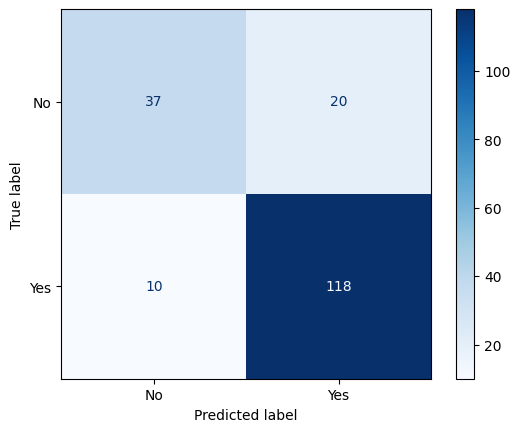

In [8]:
cm = confusion_matrix(y_test1, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])

disp.plot(cmap=plt.cm.Blues)
plt.savefig("cm_dataset1.png", dpi=150, bbox_inches='tight')
plt.show()

In [9]:
acc1 = accuracy_score(y_test1, model1.predict(X_test1))

metrics = {
    "dataset_1": {"accuracy": round(acc1, 4)}
}

with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)
    
print("Metrics successfully saved to metrics.json")

Metrics successfully saved to metrics.json
